# Random Forest Workbench

This notebook trains a Random Forest model on every CSV file in `python/output`, and randomises the row order before splitting.

The current model uses `level_t` and `learn_cnt`. The lag features `a_t_minus_5` to `a_t_minus_1` are defined below and can be enabled later by switching one flag.

## 1. Imports

Only the small set of packages needed for loading data, training the model, and reporting results are imported here.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np
from sklearn.model_selection import StratifiedKFold

## 2. Configuration

The data loading and split settings match the logistic regression notebook: the same datasets, the same feature columns, and the same 66/33 split.

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "output").exists():
            return candidate
        if (candidate / "python" / "output").exists():
            return candidate / "python"
    raise FileNotFoundError("Could not find the python/output folder.")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "output"
CSV_FILES = sorted(DATA_DIR.glob("*.csv"))

CAPPED_LIMIT = 1000

SOURCE_DATASET_NAME = "obs100000LP"
CAPPED_DATASET_NAME = "obs100000LP_capped1000"
# CAPPED_DATASET_NAME = "obs100000LP_capped2000"
# CAPPED_DATASET_NAME = "obs100000LP_capped4000"

# SOURCE_DATASET_NAME = "obs100000MP"
# CAPPED_DATASET_NAME = "obs100000MP_capped1000"
# CAPPED_DATASET_NAME = "obs100000MP_capped2000"
# CAPPED_DATASET_NAME = "obs100000MP_capped4000"

TARGET_COLUMN = "a_t"
BASE_FEATURE_COLUMNS = ["level_t", "learn_cnt"]
OPTIONAL_LAG_FEATURE_COLUMNS = ["a_t_minus_5", "a_t_minus_4", "a_t_minus_3", "a_t_minus_2", "a_t_minus_1"]
USE_LAG_FEATURES = False
FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + OPTIONAL_LAG_FEATURE_COLUMNS if USE_LAG_FEATURES else BASE_FEATURE_COLUMNS

RANDOM_SEED = 42
TEST_SIZE = 0.33

print(f"Project root: {PROJECT_ROOT}")
print("CSV files:")
for csv_file in CSV_FILES:
    print(f"- {csv_file.name}")

Project root: C:\Users\valdr\source\repos\DissertationRepo\python
CSV files:
- 1000HighPitch.csv
- obs100000LP.csv
- obs100000LP_capped1000.csv
- obs100000LP_capped2000.csv
- obs100000LP_capped4000.csv
- obs100000MP.csv
- obs100000MP_capped1000.csv
- obs100000MP_capped2000.csv
- obs100000MP_capped4000.csv
- obs1000LP.csv
- obs1000MP.csv


## 3. Data Loading

Each dataset is loaded, checked for the required columns, and shuffled before training.

In [3]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {csv_path.name}: {', '.join(missing_columns)}")
    return frame[required_columns].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


source_path = DATA_DIR / f"{SOURCE_DATASET_NAME}.csv"
if not source_path.exists():
    raise FileNotFoundError(f"Could not find source dataset: {source_path}")

source_frame = pd.read_csv(source_path)
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in source_frame.columns]
if missing_columns:
    raise ValueError(f"Missing columns in {source_path.name}: {', '.join(missing_columns)}")

# Count every level_t / learn_cnt combination.
combination_counts = (
    source_frame
    .groupby(["level_t", "learn_cnt"], dropna=False)
    .size()
    .reset_index(name="combination_count")
)

# Keep only combinations occurring MORE THAN 1000 times.
qualifying_combinations = combination_counts.loc[
    combination_counts["combination_count"] > CAPPED_LIMIT,
    ["level_t", "learn_cnt"]
]

print(f"Found {len(qualifying_combinations)} combinations occurring more than {CAPPED_LIMIT} times.")

# Keep observations belonging to qualifying combinations.
capped_frame = source_frame.merge(
    qualifying_combinations,
    on=["level_t", "learn_cnt"],
    how="inner",
)[required_columns]

# Randomly retain exactly 1000 observations per qualifying combination.
capped_frame = (
    capped_frame
    .groupby(["level_t", "learn_cnt"], group_keys=False)
    .sample(n=CAPPED_LIMIT, random_state=RANDOM_SEED)
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

capped_path = DATA_DIR / f"{CAPPED_DATASET_NAME}.csv"
capped_frame.to_csv(capped_path, index=False)

print(f"Created {CAPPED_DATASET_NAME}.csv with {len(capped_frame):,} rows.")
display(capped_frame.head())

# The model is deliberately trained only on the newly created capped dataset.
datasets = {
    CAPPED_DATASET_NAME: load_dataset(capped_path)
}

for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")


Found 29 combinations occurring more than 1000 times.
Created obs100000LP_capped1000.csv with 29,000 rows.


,level_t,learn_cnt,a_t
0,1,0,0
1,1,0,0
2,1,0,1
3,1,0,0
4,1,0,1


obs100000LP_capped1000: 29,000 rows x 3 columns


## 4. Model Training

A tiny pipeline is enough here: imputation followed by a random forest classifier.

In [4]:
def build_model() -> Pipeline:
    return make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(random_state=RANDOM_SEED, min_samples_leaf=50),
    )


def train_and_evaluate(frame: pd.DataFrame) -> dict[str, Any]:
    X_train, X_test, y_train, y_test = train_test_split(
        frame[FEATURE_COLUMNS],
        frame[TARGET_COLUMN],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=frame[TARGET_COLUMN] if frame[TARGET_COLUMN].nunique() > 1 else None,
    )

    model = build_model()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    return {
        "model": model,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred),
        "metrics": {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1_score": f1_score(y_test, y_pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        },
    }


training_results = {}
results_rows = []

for dataset_name, frame in datasets.items():
    result = train_and_evaluate(frame)
    training_results[dataset_name] = result
    results_rows.append({"dataset": dataset_name, "rows": len(frame), **result["metrics"]})

results_df = pd.DataFrame(results_rows).sort_values("dataset").reset_index(drop=True)
display(results_df)

,dataset,rows,accuracy,precision,recall,f1_score,specificity,tn,fp,fn,tp
0,obs100000LP_capped1000,29000,0.56907,0.595183,0.642651,0.618007,0.481845,2110,2269,1855,3336


### Tri-Fold Validation

This section performs a 3-fold stratified cross-validation on the dataset, printing the confusion matrix counts and performance metrics for each fold alongside their overall average.

In [ ]:
def compute_fold_metrics(y_true, y_pred) -> dict[str, Any]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def run_tri_fold_validation(frame: pd.DataFrame) -> list[dict[str, Any]]:
    X = frame[FEATURE_COLUMNS]
    y = frame[TARGET_COLUMN]

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    fold_results: list[dict[str, Any]] = []

    for fold_index, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test = X.iloc[test_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_test = y.iloc[test_idx].reset_index(drop=True)

        model = build_model()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = compute_fold_metrics(y_test, y_pred)
        metrics["fold"] = fold_index
        metrics["rows"] = len(X_test)
        fold_results.append(metrics)

    return fold_results


def summarize_tri_fold(fold_results: list[dict[str, Any]]) -> pd.DataFrame:
    columns = ["fold", "rows", "tn", "fp", "fn", "tp", "accuracy", "precision", "recall", "f1_score", "specificity"]

    rows = [{col: metrics[col] for col in columns} for metrics in fold_results]

    average_row: dict[str, Any] = {"fold": "Average"}
    for col in columns[1:]:
        average_row[col] = sum(metrics[col] for metrics in fold_results) / len(fold_results)
    rows.append(average_row)

    return pd.DataFrame(rows)


def print_fold_metrics(metrics: dict[str, Any], label: str) -> None:
    print(f"{label} (rows={metrics['rows']})")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print("-" * 60)


tri_fold_results = run_tri_fold_validation(datasets[CAPPED_DATASET_NAME])
tri_fold_summary = summarize_tri_fold(tri_fold_results)
display(tri_fold_summary)

for metrics in tri_fold_results:
    print_fold_metrics(metrics, f"Fold {metrics['fold']}")

average_metrics = {
    "rows": tri_fold_summary.iloc[-1]["rows"],
    "tn": tri_fold_summary.iloc[-1]["tn"],
    "fp": tri_fold_summary.iloc[-1]["fp"],
    "fn": tri_fold_summary.iloc[-1]["fn"],
    "tp": tri_fold_summary.iloc[-1]["tp"],
    "accuracy": tri_fold_summary.iloc[-1]["accuracy"],
    "precision": tri_fold_summary.iloc[-1]["precision"],
    "recall": tri_fold_summary.iloc[-1]["recall"],
    "f1_score": tri_fold_summary.iloc[-1]["f1_score"],
    "specificity": tri_fold_summary.iloc[-1]["specificity"],
}
print_fold_metrics(average_metrics, "Average across 3 folds")


,fold,rows,tn,fp,fn,tp,accuracy,precision,recall,f1_score,specificity
0,1,9667.000000,1409.000000,3014.0,1243.0,4001.000000,0.559636,0.570349,0.762967,0.652745,0.318562
1,2,9667.000000,2431.000000,1993.0,2230.0,3013.000000,0.563153,0.601878,0.574671,0.587960,0.549503
2,3,9666.000000,1951.000000,2472.0,1699.0,3544.000000,0.568487,0.589096,0.675949,0.629541,0.441103
3,Average,9666.666667,1930.333333,2493.0,1724.0,3519.333333,0.563759,0.587108,0.671196,0.623415,0.436389


Fold 1 (rows=9667)
TN=1409  FP=3014  FN=1243  TP=4001
Accuracy: 0.5596
Precision: 0.5703
Recall: 0.7630
F1 score: 0.6527
Specificity: 0.3186
------------------------------------------------------------
Fold 2 (rows=9667)
TN=2431  FP=1993  FN=2230  TP=3013
Accuracy: 0.5632
Precision: 0.6019
Recall: 0.5747
F1 score: 0.5880
Specificity: 0.5495
------------------------------------------------------------
Fold 3 (rows=9666)
TN=1951  FP=2472  FN=1699  TP=3544
Accuracy: 0.5685
Precision: 0.5891
Recall: 0.6759
F1 score: 0.6295
Specificity: 0.4411
------------------------------------------------------------
Average across 3 folds (rows=9666.666666666666)
TN=1930.3333333333333  FP=2493.0  FN=1724.0  TP=3519.3333333333335
Accuracy: 0.5638
Precision: 0.5871
Recall: 0.6712
F1 score: 0.6234
Specificity: 0.4364
------------------------------------------------------------


## 5. Results Details

The summary below prints the confusion matrix counts and the classification report for each dataset.

In [6]:
def show_metrics(dataset_name: str, result: dict[str, Any]) -> None:
    metrics = result["metrics"]
    print(f"Dataset: {dataset_name}")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print(classification_report(result["y_test"], result["y_pred"], zero_division=0))
    print("-" * 60)


for dataset_name, result in training_results.items():
    show_metrics(dataset_name, result)

Dataset: obs100000LP_capped1000
TN=2110  FP=2269  FN=1855  TP=3336
Accuracy: 0.5691
Precision: 0.5952
Recall: 0.6427
F1 score: 0.6180
Specificity: 0.4818
              precision    recall  f1-score   support

           0       0.53      0.48      0.51      4379
           1       0.60      0.64      0.62      5191

    accuracy                           0.57      9570
   macro avg       0.56      0.56      0.56      9570
weighted avg       0.57      0.57      0.57      9570

------------------------------------------------------------


## 6. Validation data plots

Class plots for learn count against predicted probability

,level_t,learn_cnt,number_of_appearances,empirical_success_rate,model_success_rate
0,1,0,322,0.531056,0.467600
1,1,1,342,0.593567,0.610983
2,1,2,361,0.675900,0.654898
3,1,3,362,0.709945,0.676792
4,1,4,313,0.693291,0.651910
5,1,5,329,0.696049,0.700407
6,2,0,336,0.351190,0.378974
7,2,1,346,0.430636,0.497075
8,2,2,319,0.589342,0.560576
9,2,3,314,0.550955,0.591228


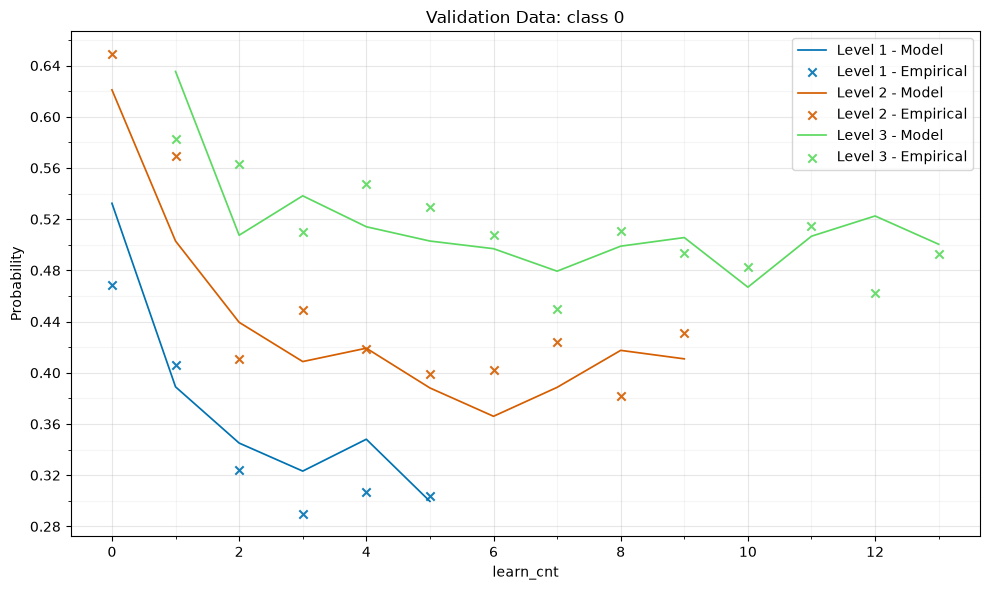

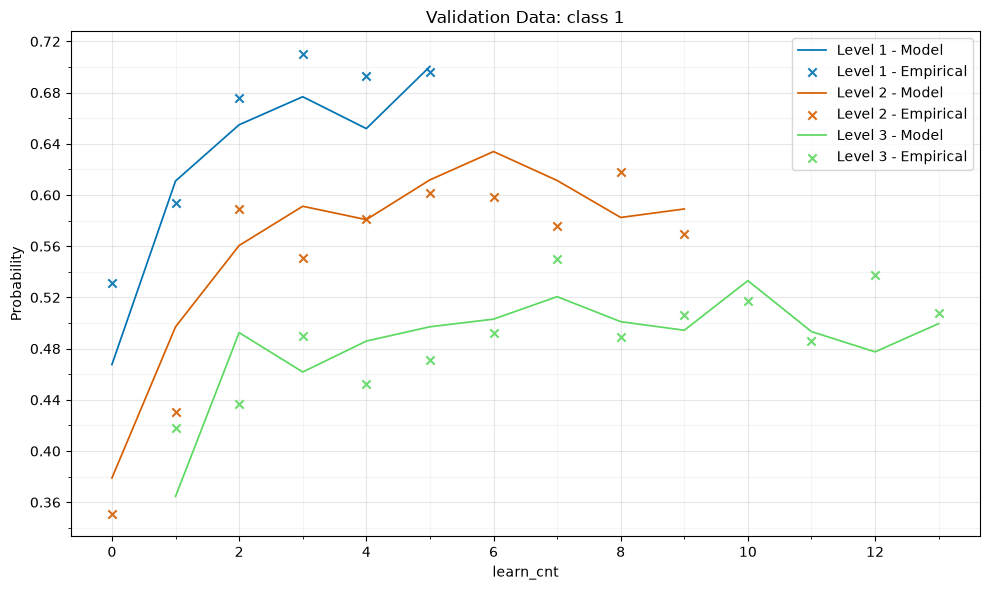

In [7]:
validation_result = training_results[CAPPED_DATASET_NAME]
validation_data = validation_result["X_test"].copy()
validation_data["a_t"] = validation_result["y_test"].to_numpy()

# Predicted probability of class 1 for every validation observation.
validation_data["model_probability"] = (
    validation_result["model"]
    .predict_proba(validation_data[FEATURE_COLUMNS])[:, 1]
)

# One row per level_t / learn_cnt combination in the validation set.
validation_combination_table = (
    validation_data
    .groupby(["level_t", "learn_cnt"], as_index=False)
    .agg(
        number_of_appearances=("a_t", "size"),
        empirical_success_rate=("a_t", "mean"),
        model_success_rate=("model_probability", "mean"),
    )
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)
display(validation_combination_table)

# ---------------------------------------------------------------------------
# Validation probability plots
# ---------------------------------------------------------------------------
levels = sorted(validation_data["level_t"].dropna().unique())
colours = {1: "#0072B2", 2: "#D55E00", 3: "#5CD960"}

class_columns = [
    (0, "probability_class_0", "Validation Data: class 0"),
    (1, "probability_class_1", "Validation Data: class 1"),
]

validation_probabilities = validation_result["model"].predict_proba(validation_data[FEATURE_COLUMNS])
validation_data["probability_class_0"] = validation_probabilities[:, 0]
validation_data["probability_class_1"] = validation_probabilities[:, 1]

def plot_validation_class(class_value: int, probability_column: str, title: str) -> None:
    fig, axis = plt.subplots(figsize=(10, 6))
    for level in levels:
        level_frame = validation_data.loc[
            validation_data["level_t"] == level,
            ["learn_cnt", probability_column, "a_t"]
        ]
        if level_frame.empty:
            continue

        # Model line: mean predicted probability per learn_cnt, no point markers.
        model_frame = (
            level_frame
            .groupby("learn_cnt", as_index=False)[probability_column]
            .mean()
            .sort_values("learn_cnt")
        )

        # Empirical crosses: observed rate of the target class per learn_cnt.
        empirical_frame = (
            level_frame
            .assign(is_class=(level_frame["a_t"] == class_value).astype(float))
            .groupby("learn_cnt", as_index=False)["is_class"]
            .mean()
            .sort_values("learn_cnt")
        )

        plot_colour = colours.get(level)
        line_kwargs = {
            "linestyle": "-",
            "linewidth": 1.25,
            "zorder": 2,
            "label": f"Level {level} - Model",
        }
        scatter_kwargs = {
            "marker": "x",
            "s": 36,
            "alpha": 0.9,
            "zorder": 3,
            "label": f"Level {level} - Empirical",
        }

        if plot_colour is not None:
            line_kwargs["color"] = plot_colour
            scatter_kwargs["color"] = plot_colour

        axis.plot(model_frame["learn_cnt"], model_frame[probability_column], **line_kwargs)
        axis.scatter(empirical_frame["learn_cnt"], empirical_frame["is_class"], **scatter_kwargs)

    axis.set_xlabel("learn_cnt")
    axis.set_ylabel("Probability")
    axis.set_title(title)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    axis.xaxis.set_minor_locator(AutoMinorLocator(2))
    axis.yaxis.set_major_locator(MaxNLocator(nbins=10))
    axis.yaxis.set_minor_locator(AutoMinorLocator(2))
    axis.grid(True, which="major", alpha=0.3)
    axis.grid(True, which="minor", alpha=0.12)
    axis.legend()
    plt.tight_layout()
    plt.show()

for class_value, probability_column, title in class_columns:
    plot_validation_class(class_value, probability_column, title)


## 7. Manual Prediction

Use this section to test a single row manually.

In [8]:
example_dataset = CAPPED_DATASET_NAME
model = training_results[example_dataset]["model"]

custom_input = pd.DataFrame([{
    "level_t": 2,
    "learn_cnt": 7,
    # "a_t_minus_5": 0,
    # "a_t_minus_4": 0,
    # "a_t_minus_3": 0,
    # "a_t_minus_2": 0,
    # "a_t_minus_1": 0,
}])

print(f"Prediction for dataset: {example_dataset}")
display(custom_input)
print(f"Predicted class: {model.predict(custom_input)[0]}")
print(f"Predicted probability of class 1: {model.predict_proba(custom_input)[0, 1]:.4f}")


Prediction for dataset: obs100000LP_capped1000


,level_t,learn_cnt
0,2,7


Predicted class: 1
Predicted probability of class 1: 0.6114


## 8. How to Extend the Notebook

To add the lag columns later, change `USE_LAG_FEATURES` to `True`. That will include `a_t_minus_5` to `a_t_minus_1` without changing the rest of the notebook.